# 黑洞标量场散射截面计算

## Part 1: Schwarzschild 黑洞验证

使用 Schwarzschild 度规 ($A = 1-1/r$, $B = 1/A$, $r_h = 1$) 验证散射计算代码的正确性。

验证指标：
1. S-matrix 各分波 $|S_l| \approx 1$（幺正性）
2. 微分散射截面图形合理（前向散射增强，衍射振荡）

**注**：$\mu=0$ 为无质量标量场，$\mu \neq 0$ 为有质量场，要求 $\omega > \mu$。

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scattering import schwarzschild_scattering

# ── Schwarzschild 验证参数 ──
omega = 6
lmax = 70
epsilon = 1e-5
mu = 0.8        # 场质量（0 为无质量标量场）

result = schwarzschild_scattering(omega=omega, lmax=lmax, epsilon=epsilon, mu=mu)

# ── 幺正性检查：|S_l| 应接近 1 ──
abs_S = result.unitarity_check()
print("l\t|S_l|")
for l in range(lmax + 1):
    print(f"{l}\t{abs_S[l]:.8f}")

计算乌龟坐标...
  求解 l = 0/70 ...
  求解 l = 10/70 ...
  求解 l = 20/70 ...
  求解 l = 30/70 ...
  求解 l = 40/70 ...
  求解 l = 50/70 ...
  求解 l = 60/70 ...
  求解 l = 70/70 ...
S-matrix 幺正性: |S_l| in [0.000109, 1.000000]
计算微分散射截面...
完成！
l	|S_l|
0	0.00012283
1	0.00012289
2	0.00012275
3	0.00012186
4	0.00012103
5	0.00012350
6	0.00012302
7	0.00011822
8	0.00012614
9	0.00011551
10	0.00012321
11	0.00012686
12	0.00010936
13	0.00196639
14	0.03937007
15	0.66395376
16	0.99888810
17	0.99999824
18	1.00000000
19	1.00000000
20	1.00000000
21	1.00000000
22	1.00000000
23	1.00000000
24	1.00000000
25	1.00000000
26	1.00000000
27	1.00000000
28	1.00000000
29	1.00000000
30	1.00000000
31	1.00000000
32	1.00000000
33	1.00000000
34	1.00000000
35	1.00000000
36	1.00000000
37	1.00000000
38	1.00000000
39	1.00000000
40	1.00000000
41	1.00000000
42	1.00000000
43	1.00000000
44	1.00000000
45	1.00000000
46	1.00000000
47	1.00000000
48	1.00000000
49	1.00000000
50	1.00000000
51	1.00000000
52	1.00000000
53	1.00000000
54	1.00000000
55	1.000000

已保存 PDF: scattering_schwarzschild_w6.pdf
已保存数据: scattering_schwarzschild_w6_mu0.8.dat


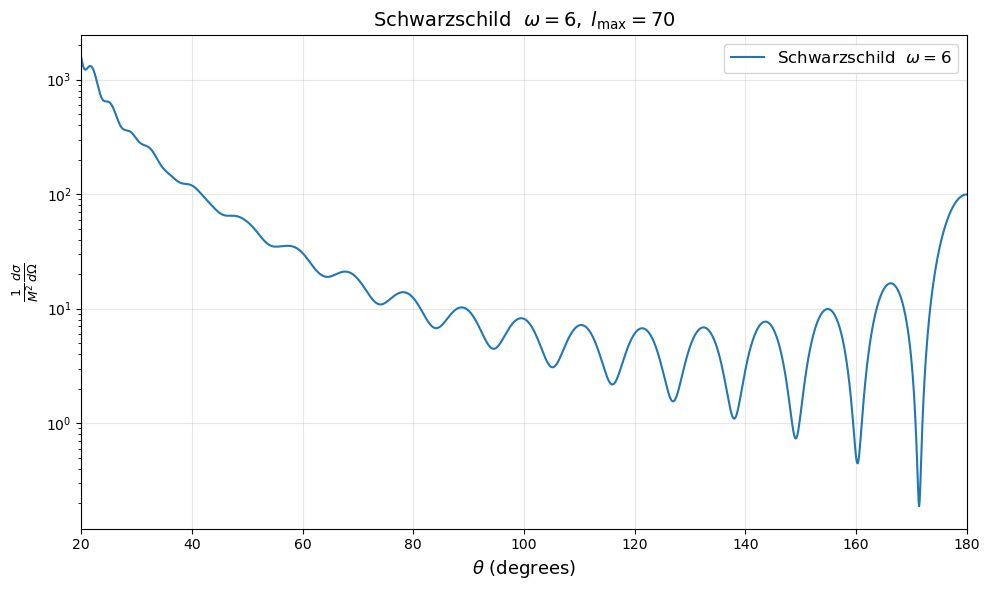

In [8]:
# ── 微分散射截面图（纵轴缩放 1/M^2 = 4） ──
M_schw = 0.5  # Schwarzschild r_h=1 时 M=1/2
scale = 1.0 / M_schw**2  # = 4

fig, ax = plt.subplots(figsize=(10, 6))
theta_deg = np.degrees(result.theta)
dsigma_scaled = result.dsigma * scale

ax.semilogy(theta_deg, dsigma_scaled, label=f'Schwarzschild  $\\omega={omega}$')
ax.set_xlabel(r'$\theta$ (degrees)', fontsize=13)
ax.set_ylabel(r'$\frac{1}{M^2}\frac{d\sigma}{d\Omega}$', fontsize=13)
ax.set_xlim(theta_deg[0], theta_deg[-1])
ax.set_title(rf'Schwarzschild  $\omega={omega},\; l_{{\max}}={lmax}$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 保存 PDF
pdf_path = f'scattering_schwarzschild_w{omega}.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f'已保存 PDF: {pdf_path}')

# 保存数据（角度 + 缩放后的截面）
data = np.column_stack([theta_deg, dsigma_scaled])
dat_path = f'scattering_schwarzschild_w{omega}_mu{mu}.dat'
np.savetxt(dat_path, data, header='theta_deg  dsigma_over_M2', fmt='%.10e')
print(f'已保存数据: {dat_path}')

plt.show()

## Part 2: EsGB 黑洞散射

调用 `esgb_solver_core.py` 求解 EsGB 黑洞度规，然后计算其散射截面并与 Schwarzschild 对比。

In [15]:
import esgb_solver_core as esgb
from scipy.interpolate import CubicSpline
from scattering import compute_scattering

# ── 求解 EsGB 黑洞 ──
rh = 1.0
alpha = 0.5
beta = -0.45
phi_h_init = 1.0

sol = esgb.solve(rh=rh, alpha=alpha, beta=beta,
                 phi_h_init=phi_h_init, N=13, verbose=True)
print(sol)

[OK]  alpha=0.5, beta=-0.45, phi_h=1.05559, M=0.79000, Q=2.47669, ||R||=1.83e-13
EsGBSolution(converged, alpha=0.5, beta=-0.45, phi_h=1.0556, M=0.7900, Q=2.4767, ||R||=1.83e-13)


In [16]:
# ── 用 EsGBSolution 的谱插值方法构建度规函数 ──
# gtt(r) = A(r)，grr(r) = B(r)
A_esgb  = sol.gtt_at      # A(r)
B_esgb  = sol.grr_at      # B(r)
dA_esgb = sol.dgtt_dr     # A'(r)
dB_esgb = sol.dgrr_dr     # B'(r)

# ── 散射计算 ──
omega = 6
lmax = 70
mu = 0.8        # 场质量（与 Part 1 保持一致）

result_esgb = compute_scattering(
    A_esgb, B_esgb, dA_esgb, dB_esgb,
    omega=omega, lmax=lmax, r_horizon=rh,
    epsilon=1e-5, mu=mu
)

# 幺正性检查
abs_S = result_esgb.unitarity_check()
print("EsGB |S_l| 范围:", f"[{abs_S.min():.8f}, {abs_S.max():.8f}]")

计算乌龟坐标...
  求解 l = 0/70 ...
  求解 l = 10/70 ...
  求解 l = 20/70 ...
  求解 l = 30/70 ...
  求解 l = 40/70 ...
  求解 l = 50/70 ...
  求解 l = 60/70 ...
  求解 l = 70/70 ...
S-matrix 幺正性: |S_l| in [0.000084, 1.000000]
计算微分散射截面...
完成！
EsGB |S_l| 范围: [0.00008372, 1.00000000]


已保存 PDF: scattering_comparison_w6_mu0.8_alpha0.5_beta-0.45.pdf
已保存 Schwarzschild 和 EsGB 数据文件


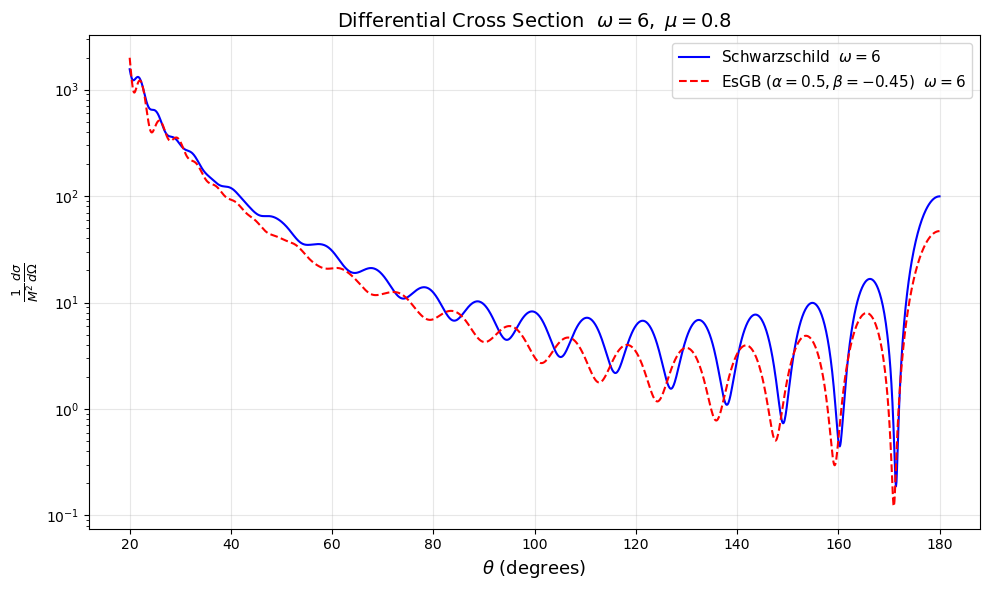

In [17]:
# ── 对比图：EsGB vs Schwarzschild（无量纲化 1/M^2） ──
M_schw = 0.5
M_esgb = 0.5

fig, ax = plt.subplots(figsize=(10, 6))

# Schwarzschild（缩放 1/M_schw^2）
theta_deg_schw = np.degrees(result.theta)
ax.semilogy(theta_deg_schw, result.dsigma / M_schw**2,
            label=f'Schwarzschild  $\\omega={omega}$', color='blue')

# EsGB（缩放 1/M_esgb^2）
theta_deg_esgb = np.degrees(result_esgb.theta)
ax.semilogy(theta_deg_esgb, result_esgb.dsigma / M_esgb**2,
            label=rf'EsGB ($\alpha={alpha},\beta={beta}$)  $\omega={omega}$',
            color='red', linestyle='--')

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=13)
ax.set_ylabel(r'$\frac{1}{M^2}\frac{d\sigma}{d\Omega}$', fontsize=13)
ax.set_title(rf'Differential Cross Section  $\omega={omega},\;\mu={mu}$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 保存 PDF
pdf_path = f'scattering_comparison_w{omega}_mu{mu}_alpha{alpha}_beta{beta}.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f'已保存 PDF: {pdf_path}')

# 保存数据
data_schw = np.column_stack([theta_deg_schw, result.dsigma / M_schw**2])
data_esgb = np.column_stack([theta_deg_esgb, result_esgb.dsigma / M_esgb**2])
np.savetxt(f'scattering_schw_w{omega}_mu{mu}.dat', data_schw,
           header='theta_deg  dsigma_over_M2', fmt='%.10e')
np.savetxt(f'scattering_esgb_w{omega}_mu{mu}_alpha{alpha}_beta{beta}.dat', data_esgb,
           header='theta_deg  dsigma_over_M2', fmt='%.10e')
print('已保存 Schwarzschild 和 EsGB 数据文件')

plt.show()

## Part 3: 总吸收截面 σ_abs 扫描

### 3.1 Schwarzschild 验证（α → 0, μ = 0）

验证指标（r_h = 1, M = 1/2）：
- 低频极限：σ_abs → 4π r_h² = 4π ≈ 12.566（面积定理）
- 高频极限：振荡收敛于几何光学截面 27π M² = 27π/4 ≈ 21.206

有质量场 μ ≠ 0 时：
- 阈值附近 ω → μ：σ_abs → ∞（因为 σ_l ∝ 1/k∞²，k∞ = √(ω²-μ²) → 0）
- 高频极限：仍然振荡收敛于 27π/4 ≈ 21.206（质量效应在高频可忽略）

In [22]:
import importlib
import scattering
importlib.reload(scattering)
from scattering import schwarzschild_absorption_scan

# ── Schwarzschild 验证：μ=0 无质量标量场 ──
results_schw, table_schw = schwarzschild_absorption_scan(
    mu=0.0,
    omega_start=0.01, omega_end=15.0, omega_step=0.5,
    epsilon=1e-5, rmax=600,
    r_sample_range=(300, 550), r_sample_step=0.5,
    rtol=1e-12, atol=1e-12,
    convergence_tol=1e-7
)

吸收截面扫描: ω ∈ [0.01, 15.01], 共 31 个点, μ=0.0
[1/31] ω = 0.0100 ...
  ω=0.0100: 收敛于 l_max=4, σ_abs=1.299405e+01
[2/31] ω = 0.5100 ...
  ω=0.5100: 收敛于 l_max=6, σ_abs=1.902439e+01
[3/31] ω = 1.0100 ...
  ω=1.0100: 收敛于 l_max=7, σ_abs=2.232821e+01
[4/31] ω = 1.5100 ...
  ω=1.5100: 收敛于 l_max=8, σ_abs=2.158445e+01
[5/31] ω = 2.0100 ...
  ω=2.0100: 收敛于 l_max=10, σ_abs=2.053055e+01
[6/31] ω = 2.5100 ...
  ω=2.5100: 收敛于 l_max=11, σ_abs=2.130551e+01
[7/31] ω = 3.0100 ...
  ω=3.0100: 收敛于 l_max=12, σ_abs=2.161305e+01
[8/31] ω = 3.5100 ...
  ω=3.5100: 收敛于 l_max=13, σ_abs=2.094554e+01
[9/31] ω = 4.0100 ...
  ω=4.0100: 收敛于 l_max=15, σ_abs=2.102565e+01
[10/31] ω = 4.5100 ...
  ω=4.5100: 收敛于 l_max=16, σ_abs=2.151960e+01
[11/31] ω = 5.0100 ...
  ω=5.0100: 收敛于 l_max=17, σ_abs=2.117677e+01
[12/31] ω = 5.5100 ...
  ω=5.5100: 收敛于 l_max=19, σ_abs=2.096494e+01
[13/31] ω = 6.0100 ...
  ω=6.0100: 收敛于 l_max=20, σ_abs=2.137368e+01
[14/31] ω = 6.5100 ...
  ω=6.5100: 收敛于 l_max=21, σ_abs=2.130902e+01
[15/31] ω = 7.0100 

In [ ]:
# ── 验证图：σ_abs vs ω，对比解析极限 ──
import numpy as np
import matplotlib.pyplot as plt

omega_arr = table_schw[:, 0]
sigma_arr = table_schw[:, 1]
lmax_arr  = table_schw[:, 2].astype(int)

# 解析极限
sigma_low  = 4 * np.pi * 1.0**2           # 4π r_h² = 4π (面积定理)
sigma_high = 27 * np.pi / 4               # π b_c² = 27π/4 (几何光学)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [3, 1]})

# 上图：σ_abs vs ω
ax1.plot(omega_arr, sigma_arr, 'bo-', markersize=4, label=r'$\sigma_{\rm abs}$ (数值)')
ax1.axhline(sigma_low, color='green', linestyle='--', alpha=0.7,
            label=rf'低频极限 $4\pi r_h^2 = {sigma_low:.3f}$')
ax1.axhline(sigma_high, color='red', linestyle='--', alpha=0.7,
            label=rf'几何光学极限 $27\pi/4 = {sigma_high:.3f}$')
ax1.set_ylabel(r'$\sigma_{\rm abs}$', fontsize=13)
ax1.set_title(r'Schwarzschild 总吸收截面验证 ($\mu=0$, $r_h=1$)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 下图：l_max_used vs ω
ax2.plot(omega_arr, lmax_arr, 'rs-', markersize=4)
ax2.set_xlabel(r'$\omega$', fontsize=13)
ax2.set_ylabel(r'$l_{\max}$ used', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('absorption_schwarzschild_validation.pdf', format='pdf', bbox_inches='tight')
print(f'低频 σ_abs(ω={omega_arr[0]:.1f}) = {sigma_arr[0]:.4f}, 理论值 4π = {sigma_low:.4f}')
print(f'高频 σ_abs(ω={omega_arr[-1]:.1f}) = {sigma_arr[-1]:.4f}, 理论值 27π/4 = {sigma_high:.4f}')
plt.show()

### 3.2 EsGB 黑洞吸收截面扫描

使用已有的 EsGB 数值解（Part 2 中的 `sol`），扫描 ω 计算 σ_abs 并与 Schwarzschild 对比。

In [ ]:
from scattering import scan_absorption

# ── EsGB 吸收截面扫描 ──
# 度规函数来自 Part 2 中已求解的 sol 对象
mu_scan = 0.8
results_esgb_abs, table_esgb_abs = scan_absorption(
    A_esgb, B_esgb, dA_esgb, dB_esgb,
    mu=mu_scan, r_horizon=rh,
    omega_start=2.0, omega_end=20.0, omega_step=0.5,
    epsilon=1e-5, rmax=600,
    r_sample_range=(300, 550), r_sample_step=0.5,
    rtol=1e-12, atol=1e-12,
    convergence_tol=1e-7
)

In [ ]:
# ── 同参数 Schwarzschild 对比（有质量场 μ=0.8） ──
results_schw_mu, table_schw_mu = schwarzschild_absorption_scan(
    mu=mu_scan,
    omega_start=2.0, omega_end=20.0, omega_step=0.5,
    epsilon=1e-5, rmax=600,
    r_sample_range=(300, 550), r_sample_step=0.5,
    rtol=1e-12, atol=1e-12,
    convergence_tol=1e-7
)

In [ ]:
# ── 对比图：EsGB vs Schwarzschild 吸收截面 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={'height_ratios': [3, 1]})

omega_esgb = table_esgb_abs[:, 0]
sigma_esgb = table_esgb_abs[:, 1]
lmax_esgb  = table_esgb_abs[:, 2].astype(int)

omega_schw_m = table_schw_mu[:, 0]
sigma_schw_m = table_schw_mu[:, 1]
lmax_schw_m  = table_schw_mu[:, 2].astype(int)

sigma_high = 27 * np.pi / 4  # 几何光学极限

ax1.plot(omega_schw_m, sigma_schw_m, 'b^-', markersize=4,
         label=rf'Schwarzschild $\mu={mu_scan}$')
ax1.plot(omega_esgb, sigma_esgb, 'ro-', markersize=4,
         label=rf'EsGB ($\alpha={alpha},\beta={beta}$) $\mu={mu_scan}$')
ax1.axhline(sigma_high, color='gray', linestyle='--', alpha=0.5,
            label=rf'几何光学极限 $27\pi/4 = {sigma_high:.3f}$')
ax1.set_ylabel(r'$\sigma_{\rm abs}$', fontsize=13)
ax1.set_title(rf'总吸收截面 $\sigma_{{\rm abs}}$ vs $\omega$ ($\mu={mu_scan}$)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(omega_schw_m, lmax_schw_m, 'b^-', markersize=4, label='Schwarzschild')
ax2.plot(omega_esgb, lmax_esgb, 'ro-', markersize=4, label='EsGB')
ax2.set_xlabel(r'$\omega$', fontsize=13)
ax2.set_ylabel(r'$l_{\max}$ used', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'absorption_comparison_mu{mu_scan}_alpha{alpha}_beta{beta}.pdf',
            format='pdf', bbox_inches='tight')

# 保存数据
np.savetxt(f'absorption_esgb_mu{mu_scan}_alpha{alpha}_beta{beta}.dat',
           table_esgb_abs, header='omega  sigma_abs  lmax_used', fmt='%.10e')
np.savetxt(f'absorption_schw_mu{mu_scan}.dat',
           table_schw_mu, header='omega  sigma_abs  lmax_used', fmt='%.10e')
print('已保存对比图和数据文件')
plt.show()